# Heart Disease Prediction with ML

## 1. Problem

Given patient clinical parameters, predict if they have heart disease (binary classification).

## 2. Data

Dataset: [UCI Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease)
Also on [Kaggle](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data).

## 3. Features (Key)

1. **age** – years
2. **sex** – 1 = male, 0 = female
3. **cp** – chest pain (0–3: typical, atypical, non-anginal, asymptomatic)
4. **trestbps** – resting BP (mm Hg)
5. **chol** – serum cholesterol (mg/dl, >200 risky)
6. **fbs** – fasting blood sugar >120 mg/dl (1 = true)
7. **restecg** – ECG results (0–2: normal, abnormal, LV hypertrophy)
8. **thalach** – max heart rate achieved
9. **exang** – exercise-induced angina (1 = yes)
10. **oldpeak** – ST depression (exercise vs rest)
11. **slope** – ST slope (0 = up, 1 = flat, 2 = down)
12. **ca** – number of major vessels (0–3)
13. **thal** – thalium stress result (1,3 = normal; 6 = fixed defect; 7 = reversible defect)
14. **target** – disease (1 = yes, 0 = no)


## Importing all the libraries and tools used
* Pandas
* Numpy
* Scikit Learn
* Matplotlib
* Seaborn

In [69]:
import pandas as pd
import numpy as np
%matplotlib inline 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve

## Importing Dataset

In [70]:
df= pd.read_csv("heart-disease-1000.csv")
df.head()
df.shape

(1000, 14)

## Data Exploration (exploratory data analysis or EDA)


In [71]:
df["target"].value_counts()

target
1    553
0    447
Name: count, dtype: int64

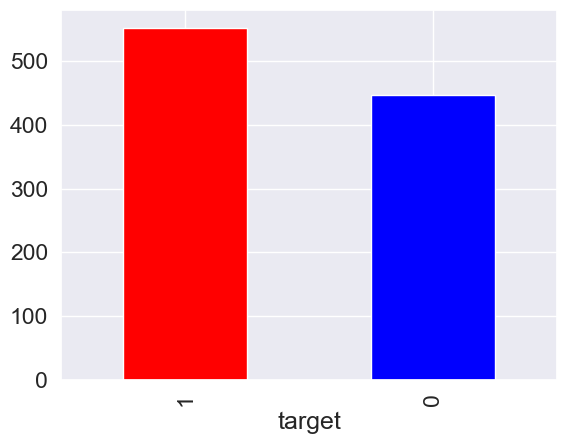

In [72]:
df["target"].value_counts().plot(kind="bar", color=["red", "blue"])
plt.show()

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1000 non-null   int64  
 1   sex       1000 non-null   int64  
 2   cp        1000 non-null   int64  
 3   trestbps  1000 non-null   int64  
 4   chol      1000 non-null   int64  
 5   fbs       1000 non-null   int64  
 6   restecg   1000 non-null   int64  
 7   thalach   1000 non-null   int64  
 8   exang     1000 non-null   int64  
 9   oldpeak   1000 non-null   float64
 10  slope     1000 non-null   int64  
 11  ca        1000 non-null   int64  
 12  thal      1000 non-null   int64  
 13  target    1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


In [74]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [75]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,54.499000,0.666000,0.998000,131.580000,247.176000,0.151000,0.535000,150.729000,0.332000,1.01180,1.406000,0.721000,2.312000,0.553000
std,9.084962,0.471876,1.046466,17.467705,53.447766,0.358228,0.528256,22.609572,0.471167,1.10594,0.619312,1.015968,0.605824,0.497432
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,213.000000,0.000000,0.000000,138.000000,0.000000,0.00000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,242.000000,0.000000,1.000000,154.000000,0.000000,0.80000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,278.000000,0.000000,1.000000,168.000000,1.000000,1.60000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,2.000000,4.000000,3.000000,1.000000


In [76]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,0,1,140,195,0,1,179,0,0.0,2,2,2,1
1,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
2,69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
3,51,1,2,94,227,0,1,154,1,0.0,2,1,3,1
4,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0


### Heart Disease Frequency according to gender

In [77]:
df.sex.value_counts()

sex
1    666
0    334
Name: count, dtype: int64

In [78]:
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,85,362
1,249,304


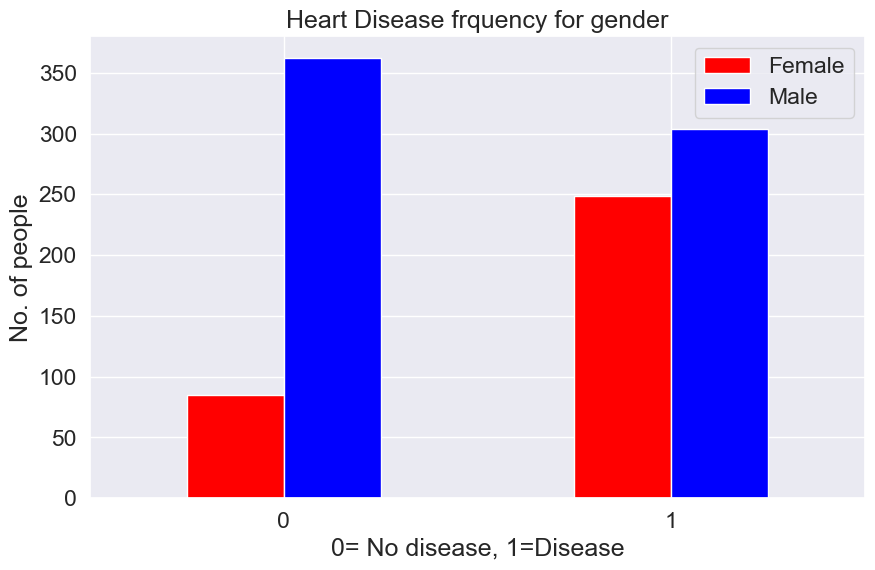

In [79]:
pd.crosstab(df.target, df.sex).plot(kind= "bar", figsize=(10,6), color=["red", "blue"])
plt.title("Heart Disease frquency for gender")
plt.xlabel("0= No disease, 1=Disease")
plt.ylabel("No. of people")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0)
plt.show()

In [80]:
df["thalach"].value_counts()

thalach
162    43
163    37
150    32
125    31
143    31
       ..
99      1
90      1
95      1
128     1
202     1
Name: count, Length: 86, dtype: int64

### Age vs. Max Heart Rate for Heart Disease

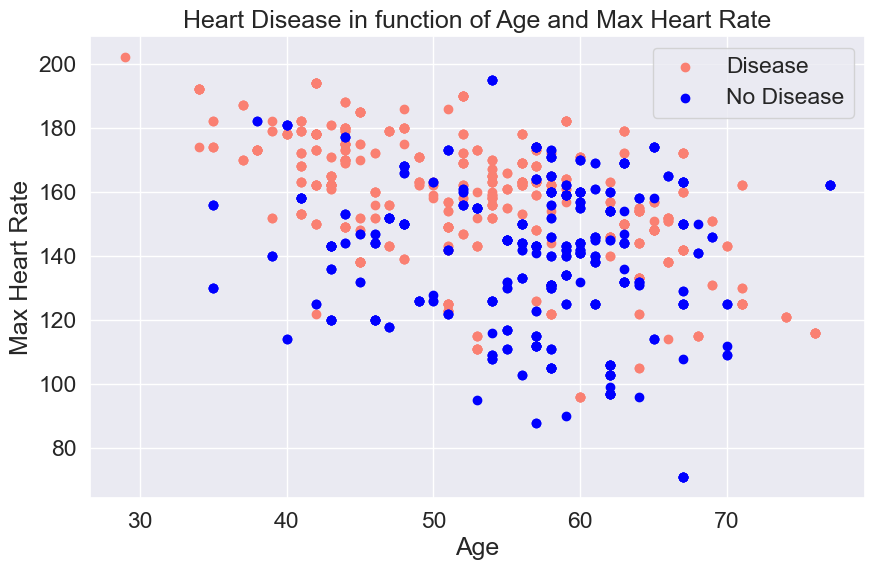

In [81]:
plt.figure(figsize=(10,6))
plt.scatter(df.age[df.target==1],
           df.thalach[df.target==1],
           c="salmon")
plt.scatter(df.age[df.target==0],
           df.thalach[df.target==0],
           c="blue")
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"])
plt.show()

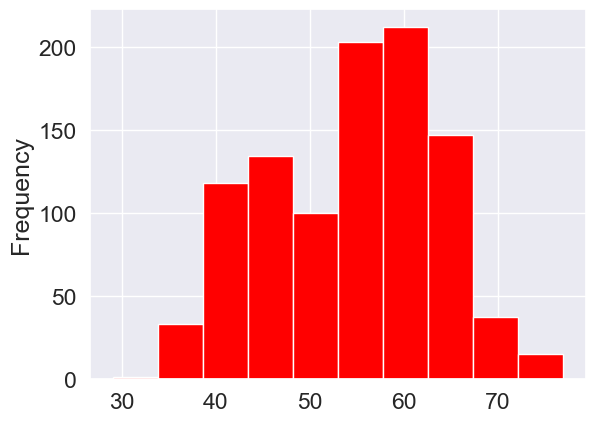

In [82]:
df.age.plot.hist(color="red")
plt.show()

## Heart Disease Frequency per Chest Pain Type
3. cp - chest pain type
* 0: Typical angina: chest pain related decrease blood supply to the...
* 1: Atypical angina: chest pain not related to heart
* 2: Non-anginal pain: typically esophageal spasms (non heart related)
* 3: Asymptomatic: chest pain not showing signs of disease

In [83]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,338,124
1,34,130
2,54,234
3,21,65


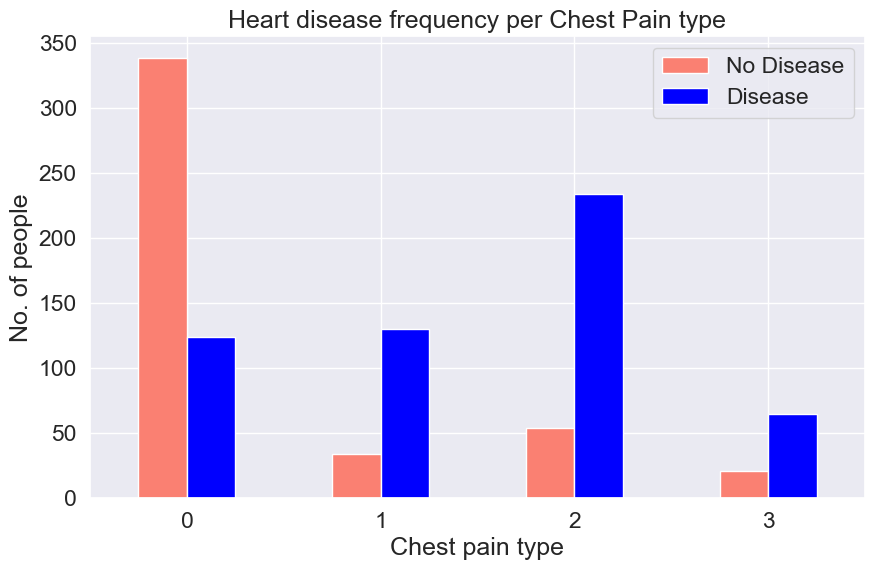

In [84]:
pd.crosstab(df.cp, df.target).plot(kind="bar", color=["salmon", "blue"], figsize=(10,6))
plt.title("Heart disease frequency per Chest Pain type")
plt.xlabel("Chest pain type")
plt.ylabel("No. of people")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0)
plt.show()

In [85]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,0,1,140,195,0,1,179,0,0.0,2,2,2,1
1,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
2,69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
3,51,1,2,94,227,0,1,154,1,0.0,2,1,3,1
4,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0


In [86]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.168197,-0.087285,0.252895,0.203243,0.104468,-0.103656,-0.386555,0.083094,0.211859,-0.158090,0.219745,0.020972,-0.189816
sex,-0.168197,1.000000,-0.052032,-0.080915,-0.172778,0.055865,-0.137779,0.027911,0.130062,0.100780,-0.008207,0.108187,0.210821,-0.274202
cp,-0.087285,-0.052032,1.000000,0.041737,-0.122069,0.043530,0.020045,0.290756,-0.459503,-0.173310,0.107828,-0.201069,-0.221644,0.463643
trestbps,0.252895,-0.080915,0.041737,1.000000,0.129599,0.135082,-0.111443,-0.007378,0.090543,0.132150,-0.039093,0.057241,0.069907,-0.119666
chol,0.203243,-0.172778,-0.122069,0.129599,1.000000,0.021196,-0.118456,-0.010257,0.117880,0.051124,0.022667,0.088818,0.115251,-0.114357
fbs,0.104468,0.055865,0.043530,0.135082,0.021196,1.000000,-0.088788,-0.009032,0.070385,0.057401,-0.118692,0.220386,-0.000517,-0.115175
restecg,-0.103656,-0.137779,0.020045,-0.111443,-0.118456,-0.088788,1.000000,0.026483,-0.107059,-0.046627,0.078910,-0.113279,-0.043539,0.175785
thalach,-0.386555,0.027911,0.290756,-0.007378,-0.010257,-0.009032,0.026483,1.000000,-0.331042,-0.345675,0.283809,-0.188281,-0.108775,0.385463
exang,0.083094,0.130062,-0.459503,0.090543,0.117880,0.070385,-0.107059,-0.331042,1.000000,0.333068,-0.198252,0.181150,0.274991,-0.459539
oldpeak,0.211859,0.100780,-0.173310,0.132150,0.051124,0.057401,-0.046627,-0.345675,0.333068,1.000000,-0.529481,0.217370,0.189320,-0.432195


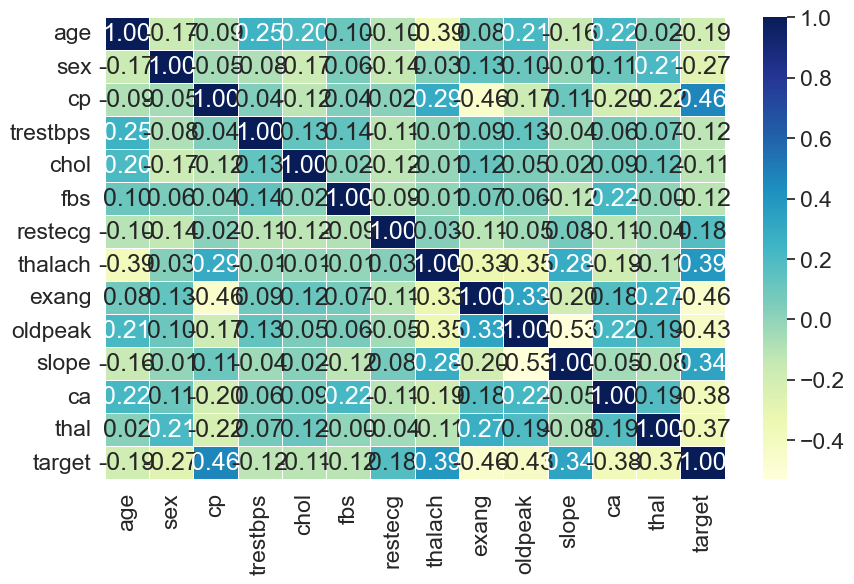

In [87]:
corr_matrix= df.corr()
fig, ax= plt.subplots(figsize=(10,6))
ax= sns.heatmap(corr_matrix,annot=True,linewidths=0.5,fmt=".2f",cmap="YlGnBu")
plt.show()

## 5.Modelling

In [88]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,0,1,140,195,0,1,179,0,0.0,2,2,2,1
1,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
2,69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
3,51,1,2,94,227,0,1,154,1,0.0,2,1,3,1
4,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0


In [89]:
X= df.drop("target", axis=1)
Y=df["target"]

In [90]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,0,1,140,195,0,1,179,0,0.0,2,2,2
1,46,1,0,120,249,0,0,144,0,0.8,2,0,3
2,69,1,3,160,234,1,0,131,0,0.1,1,1,2
3,51,1,2,94,227,0,1,154,1,0.0,2,1,3
4,50,1,2,140,233,0,1,163,0,0.6,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,66,0,2,146,278,0,0,152,0,0.0,1,1,2
996,58,0,0,130,197,0,1,131,0,0.6,1,0,2
997,53,0,2,128,216,0,0,115,0,0.0,2,0,0
998,52,1,3,152,298,1,1,178,0,1.2,1,0,3


In [91]:
Y

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    1
999    0
Name: target, Length: 1000, dtype: int64

In [92]:
np.random.seed(42)
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2)

Now we've got our data split into training and test sets, it's...
We'll train it (find the patterns) on the training set.
And we'll test it (use the patterns) on the test set.
We are going to try 3 different machine learning models:
1. `Logistc Regression`
2. `K- Nearest Neighbors Classifier`
3. `Random Forest Classifier`

In [93]:
models= {"Logistic Regresssion": LogisticRegression(),
        "KNN": KNeighborsClassifier(),
        "Random Forest": RandomForestClassifier()}
def fit_score (models, X_train, X_test, Y_train, Y_test):
    """
    Fits and evaluates given machine learning models.
    models: a dict of different Scikit-Learn machine Learning Models
    X_train: training data (no labels)
    X_test: testing data (no labels)
    Y_train: training labels
    Y_test: test labels
    """
    np.random.seed(42)
    model_scores={}
    for name, model in models.items():
        model.fit(X_train, Y_train)
        model_scores[name]= model.score(X_test, Y_test)
    return model_scores

In [94]:
model_scores= fit_score(models, X_train, X_test, Y_train, Y_test)
model_scores

C:\Users\vm336\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regresssion': 0.85, 'KNN': 0.825, 'Random Forest': 0.985}

### Model Comparison

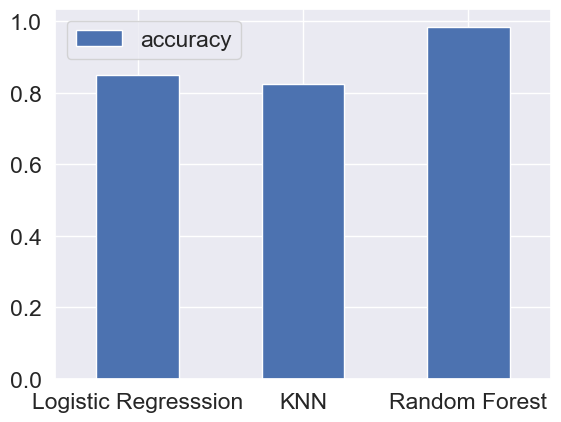

In [95]:
model_compare= pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot(kind="bar")
plt.xticks(rotation=0)
plt.show()

Let's look at the following:
* Hyperparameter tuning
* Feature importance
* confusion matrix
* cross validation
* precision
* recall
* f1 score
* classification report
* roc curve
* area under the curve (AUC)
## Hyperparameter tuning by hand

In [96]:
train_scores=[]
test_scores=[]
neighbors = range(1,21)
knn= KNeighborsClassifier()
for i in neighbors:
    knn.set_params(n_neighbors=i)
    knn.fit(X_train, Y_train)
    train_scores.append(knn.score(X_train, Y_train))
    test_scores.append(knn.score(X_test, Y_test))

In [97]:
train_scores

[1.0,
 0.99125,
 0.9825,
 0.9375,
 0.905,
 0.885,
 0.8625,
 0.8475,
 0.8475,
 0.84,
 0.83,
 0.81875,
 0.8175,
 0.82,
 0.8075,
 0.79,
 0.78875,
 0.7825,
 0.77625,
 0.77125]

In [98]:
test_scores

[0.975,
 0.965,
 0.935,
 0.87,
 0.825,
 0.8,
 0.78,
 0.76,
 0.765,
 0.75,
 0.76,
 0.76,
 0.775,
 0.785,
 0.775,
 0.76,
 0.755,
 0.76,
 0.755,
 0.745]

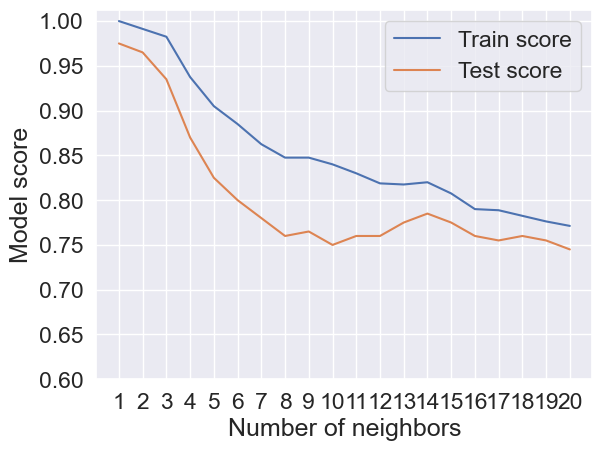

Maximum KNN score on the test datta: 97.50%


In [99]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()
plt.xticks(np.arange(1, 21, 1))
plt.yticks(np.arange(0.6, 1.05, 0.05))
plt.show()
print(f"Maximum KNN score on the test datta: {max(test_scores)*100:.2f}%")

## Hyperparameters tuning with RandomizedSearchCV
we are going to tune tune:
* LogisticRegression()
* RandomForestClassifier()
....using RandomizedSearchCV

In [100]:
log_reg_grid= {"C": np.logspace(-4,4,20),"solver": ["liblinear"]}
rf_grid={"n_estimators": np.arange(10,1000,50),"max_depth": [None, 3,5,10],"min_samples_split": np.arange(2,20,2),"min_samples_leaf": np.arange(1,20,2)}

now we've got hyperparameter grids setup for each of our models, let's...

In [101]:
np.random.seed(42)
rs_log_reg = RandomizedSearchCV(LogisticRegression(),param_distributions= log_reg_grid,cv=5,n_iter=20,verbose= True)
rs_log_reg.fit(X_train, Y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [102]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(1.623776739188721)}

In [103]:
rs_log_reg.score(X_test, Y_test)

0.85

now we've tuned logistic regression, let's do the same for RandomForestClassifier()

In [104]:
np.random.seed(42)
rs_tf= RandomizedSearchCV(RandomForestClassifier(),param_distributions= rf_grid,cv=5,n_iter=20,verbose=True)
rs_tf.fit(X_train, Y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [105]:
rs_tf.best_params_

{'n_estimators': np.int64(510),
 'min_samples_split': np.int64(14),
 'min_samples_leaf': np.int64(1),
 'max_depth': None}

In [106]:
rs_tf.score(X_test, Y_test)

0.98

## Hyperparameter Tuning with GridSearchCV
Since our LogisticRegression model provides the best scores so far, we'll try...

In [107]:
log_reg_grid = {"C": np.logspace(-4,4,30),"solver": ["liblinear"]}
gs_log_reg = GridSearchCV(LogisticRegression(),param_grid= log_reg_grid,cv=5,verbose =True)
gs_log_reg.fit(X_train, Y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                         'solver': ['liblinear']},
             verbose=True)

In [108]:
gs_log_reg.best_params_

{'C': np.float64(9.236708571873866), 'solver': 'liblinear'}

In [109]:
gs_log_reg.score(X_test, Y_test)

0.85

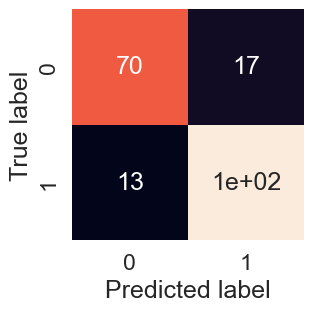

In [110]:
import seaborn as sns
sns.set(font_scale=1.5)
def plot_conf_mat(y_test, y_preds):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(Y_test, y_preds),annot=True,cbar=False)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
plot_conf_mat(  Y_test, y_preds)

## Evaluating our tuned machine learning classifier, beyond accuracy
* ROC curve and AUC score
* Confusion Matrix
* Classification report
* Precision
* Recall
* F1 Score

In [111]:
y_preds= gs_log_reg.predict(X_test)
y_probs = gs_log_reg.predict_proba(X_test)[:,1]

In [112]:
Y_test

521    1
737    0
740    1
660    0
411    0
      ..
408    0
332    0
208    1
613    0
78     1
Name: target, Length: 200, dtype: int64

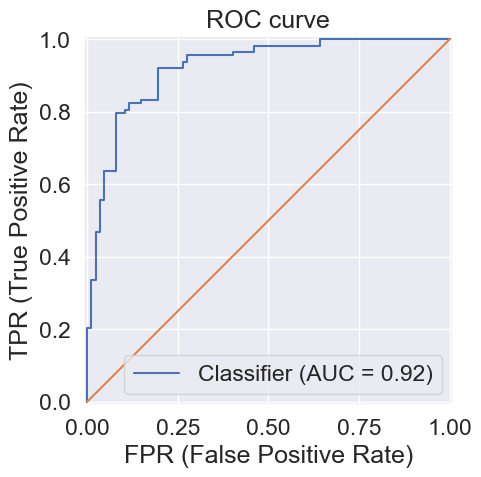

In [113]:
fpr, tpr, thresholds = roc_curve(y_true= Y_test,y_score= y_probs)
RocCurveDisplay.from_predictions(Y_test, y_probs)
plt.title("ROC curve")
plt.grid(True)
plt.plot([0,1], [0,1])
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.show()

In [114]:
Y_test[:10]

521    1
737    0
740    1
660    0
411    0
678    0
626    1
513    0
859    0
136    1
Name: target, dtype: int64

In [115]:
y_preds[:10]

array([1, 0, 1, 0, 0, 1, 1, 0, 0, 1])

In [116]:
print(confusion_matrix(Y_test,y_preds))

[[ 70  17]
 [ 13 100]]


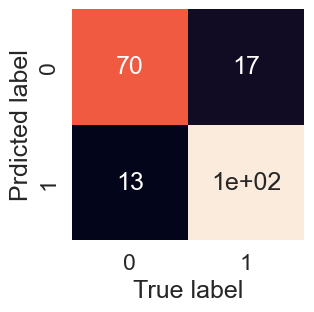

In [117]:
sns.set(font_scale=1.5)
def plot_conf_mat(Y_test, y_preds):
    fig, ax= plt.subplots(figsize=(3,3))
    ax=sns.heatmap(confusion_matrix(Y_test, y_preds),annot=True,cbar=False)
    plt.xlabel("True label")
    plt.ylabel("Prdicted label")
    plt.show()
plot_conf_mat(Y_test, y_preds)

Now we've got the roc curve, an auc metric and a confusion...

In [118]:
print(classification_report(Y_test, y_preds))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82        87
           1       0.85      0.88      0.87       113

    accuracy                           0.85       200
   macro avg       0.85      0.84      0.85       200
weighted avg       0.85      0.85      0.85       200



### Calculate evaluation metrics using cross- validation
we are going to calculate accuracy, precision, recall and f1-score of our model...

In [119]:
gs_log_reg.best_params_

{'C': np.float64(9.236708571873866), 'solver': 'liblinear'}

In [120]:
clf= LogisticRegression(C=0.20433597178569418,solver= "liblinear")

In [121]:
cv_acc= cross_val_score(clf,X,Y,cv=5,scoring="accuracy")
cv_acc

array([0.825, 0.875, 0.845, 0.81 , 0.87 ])

In [122]:
cv_acc= np.mean(cv_acc)
cv_acc

np.float64(0.845)

In [123]:
cv_precision= cross_val_score(clf,X,Y,cv=5,scoring="precision")
cv_precision= np.mean(cv_precision)
cv_precision

np.float64(0.8190294755135514)

In [124]:
cv_f1=cross_val_score(clf,X,Y,cv=5,scoring="f1")
cv_f1= np.mean(cv_f1)
cv_f1

np.float64(0.8681621667453505)

In [125]:
cv_recall=cross_val_score(clf,X,Y,cv=5,scoring="recall")
cv_recall= np.mean(cv_recall)
cv_recall

np.float64(0.9240786240786241)

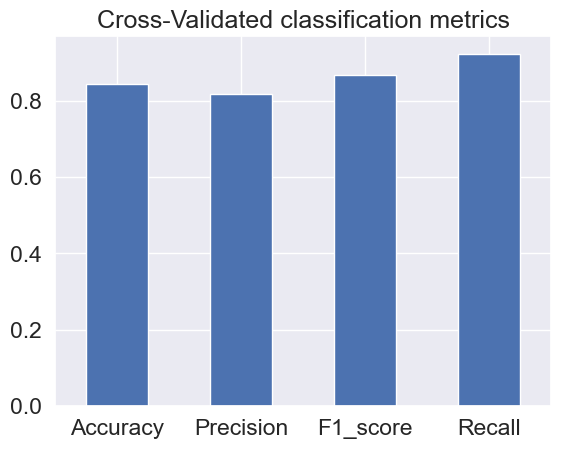

In [126]:
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,"Precision": cv_precision,"F1_score": cv_f1,"Recall": cv_recall},index=[0])
cv_metrics.T.plot.bar(title= "Cross-Validated classification metrics",legend= False)
plt.xticks(rotation=0)
plt.show()

### Feature Importance
feature importance is another way of asking, "which features contributed most to
Finding feature importance is different for each machine learning model.
Let's find the feature importance for our LogisticRegression model

In [127]:
gs_log_reg.best_params_
clf= LogisticRegression(C= 0.20433597178569418,solver="liblinear")
clf.fit(X_train, Y_train)

LogisticRegression(C=0.20433597178569418, solver='liblinear')

In [128]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,0,1,140,195,0,1,179,0,0.0,2,2,2,1
1,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
2,69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
3,51,1,2,94,227,0,1,154,1,0.0,2,1,3,1
4,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0


In [129]:
clf.coef_

array([[ 0.01462934, -1.28901997,  0.76982667, -0.01755307, -0.00411284,
        -0.24987854,  0.6364698 ,  0.03005873, -0.47908873, -0.48098532,
         0.7801252 , -0.65784892, -1.01589826]])

In [130]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,0,1,140,195,0,1,179,0,0.0,2,2,2,1
1,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
2,69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
3,51,1,2,94,227,0,1,154,1,0.0,2,1,3,1
4,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0


In [131]:
feature_dict= dict(zip(df.columns, list(clf.coef_[0])))
feature_dict

{'age': np.float64(0.014629341164070418),
 'sex': np.float64(-1.2890199695557611),
 'cp': np.float64(0.769826668327324),
 'trestbps': np.float64(-0.017553069096472314),
 'chol': np.float64(-0.00411284309529282),
 'fbs': np.float64(-0.2498785419814581),
 'restecg': np.float64(0.6364698014893784),
 'thalach': np.float64(0.030058725209799145),
 'exang': np.float64(-0.4790887256861789),
 'oldpeak': np.float64(-0.48098531507478626),
 'slope': np.float64(0.780125200218918),
 'ca': np.float64(-0.6578489197699424),
 'thal': np.float64(-1.0158982603672853)}

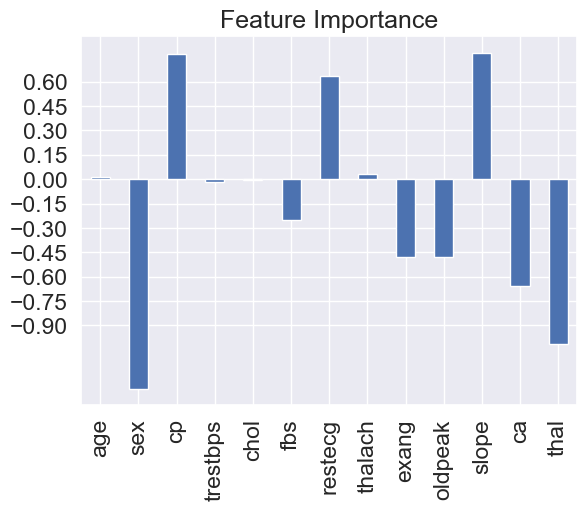

In [132]:
feature_df= pd.DataFrame(feature_dict, index=[0])
feature_df.T.plot.bar(title= "Feature Importance", legend=False)
plt.yticks(np.arange(-0.9, 0.7, 0.15))
plt.show()

In [133]:
pd.crosstab(df["sex"], df["target"])

target,0,1
sex,,
0,85,249
1,362,304


In [134]:
pd.crosstab(df["slope"], df["target"])

target,0,1
slope,,
0,37,34
1,295,157
2,115,362


slope - the slope of the peak exercise ST segment
* 0: Upsloping: better heart rate with excercise (uncommon)
* 1: Flatsloping: minimal change (typical healthy heart)
* 2: Downslopings: signs of unhealthy heart